# Problem Statement

Problem Statement

The used car market in India lacks a standardized and transparent pricing mechanism.
Prices for similar cars vary significantly due to differences in seller perception, incomplete market information, and subjective valuation methods.

As a result:

    Sellers may overprice or underprice vehicles, leading to financial loss or delayed sales.

    Buyers struggle to identify fair market value and are vulnerable to overpaying.

    Dealerships often have an information advantage over individual buyers and sellers.

The core problem is to predict a fair selling price for a used car based on its specifications and historical data, thereby reducing subjectivity and improving decision-making.

# Objective

Objective

The objective of this project is to build a Machine Learning regression model that predicts the selling price of used cars using their technical specifications and ownership details.

Specific objectives include:

    Accurately predicting used car prices with acceptable error.

    Understanding which features most influence car prices.

    Creating a scalable and reproducible ML pipeline.

    Establishing a baseline regression model for further improvement.

    Demonstrating end-to-end ML workflow for real-world data.

Success Criteria

    R² score ≥ 0.75

    Reasonable MAE and RMSE for Indian used car prices

    Comparable train and test performance (no severe overfitting)

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split   # --> for train-test split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score   # --> for evaluating model's performance
from sklearn.preprocessing import StandardScaler   # --> for Scaling
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE   # --> for handling Multicollinearity & Feature Selection
from sklearn.linear_model import Ridge, Lasso, ElasticNet   # --> for Regularization
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV   # --> for Cross-Validation

### Load Data: Car details v3.csv

In [4]:
df = pd.read_csv('Data/Vehicle.csv')
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


# Data cleaning & preprocessing

In [5]:
df.shape

(8128, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


# Data Description

The dataset used in this project is sourced from CarDekho (via Kaggle) and represents the Indian used car market.

    Rows: 8,128

    Columns: 13

    Target variable: selling_price

| Feature       | Description            |
| ------------- | ---------------------- |
| name          | Car brand and model    |
| year          | Manufacturing year     |
| selling_price | Target variable (INR)  |
| km_driven     | Distance driven        |
| fuel          | Fuel type              |
| seller_type   | Individual or Dealer   |
| transmission  | Manual / Automatic     |
| owner         | Ownership history      |
| mileage       | Fuel efficiency (kmpl) |
| engine        | Engine capacity (CC)   |
| max_power     | Power output (bhp)     |
| torque        | Torque specification   |
| seats         | Seating capacity       |

The target variable selling_price is right-skewed, with most cars priced below ₹6–7 lakhs and a small number of luxury vehicles priced significantly higher.

In [7]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [8]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [9]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

In [10]:
# Null values count
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [11]:
# Duplicate values count
df.duplicated().value_counts()

# Alternative --> df.duplicated().sum()

False    6926
True     1202
Name: count, dtype: int64

In [12]:
# Duplicate values handling --> Drop
df.drop_duplicates(inplace=True)
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0
8122,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0


In [13]:
# Reset index
df.reset_index(drop = True, inplace=True)
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6921,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0
6922,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0
6923,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
6924,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0


# Key Challenges

1. Mixed Data Types

Columns like mileage, engine, and max_power contained numeric values stored as strings with units.

Required string parsing and numeric extraction.

2. Missing Values

Multiple columns contained missing values.

Required imputation to preserve dataset size.

3. Skewed Distributions

selling_price, km_driven, and max_power were heavily right-skewed.

Violated linear regression assumptions.

4. Outliers

Presence of luxury cars and high mileage vehicles.

Risk of distortion in regression coefficients.

5. Categorical Encoding

High cardinality in brand names (30+ categories).

Required one-hot encoding, increasing dimensionality.

6. Multicollinearity

Strong correlation between features like engine and max_power.

Risk of unstable coefficients.

### Converting Mileage from object --> float

In [14]:
df['mileage'].unique()

array(['23.4 kmpl', '21.14 kmpl', '17.7 kmpl', '23.0 kmpl', '16.1 kmpl',
       '20.14 kmpl', '17.3 km/kg', '23.59 kmpl', '20.0 kmpl',
       '19.01 kmpl', '17.3 kmpl', '19.3 kmpl', nan, '18.9 kmpl',
       '18.15 kmpl', '24.52 kmpl', '19.7 kmpl', '22.54 kmpl', '21.0 kmpl',
       '25.5 kmpl', '26.59 kmpl', '21.5 kmpl', '20.3 kmpl', '21.4 kmpl',
       '24.7 kmpl', '18.2 kmpl', '16.8 kmpl', '24.3 kmpl', '14.0 kmpl',
       '18.6 kmpl', '33.44 km/kg', '23.95 kmpl', '17.0 kmpl',
       '20.63 kmpl', '13.93 kmpl', '16.0 kmpl', '17.8 kmpl', '18.5 kmpl',
       '12.55 kmpl', '12.99 kmpl', '14.8 kmpl', '13.5 kmpl', '26.0 kmpl',
       '20.65 kmpl', '27.3 kmpl', '11.36 kmpl', '17.68 kmpl',
       '14.28 kmpl', '18.53 kmpl', '14.84 kmpl', '21.12 kmpl',
       '20.36 kmpl', '21.27 kmpl', '18.16 kmpl', '22.0 kmpl', '25.1 kmpl',
       '20.51 kmpl', '21.66 kmpl', '25.2 kmpl', '22.9 kmpl', '16.02 kmpl',
       '20.54 kmpl', '22.77 kmpl', '15.71 kmpl', '23.1 kmpl',
       '19.02 kmpl', '19.81 kmpl'

In [15]:
df['mileage'] = df['mileage'].str.replace('kmpl','',regex=False).str.strip()
df['mileage'] = df['mileage'].str.replace('km/kg','',regex=False).str.strip()
df['mileage']

0        23.4
1       21.14
2        17.7
3        23.0
4        16.1
        ...  
6921     18.9
6922    22.54
6923     18.5
6924     16.8
6925     19.3
Name: mileage, Length: 6926, dtype: object

In [16]:
df['mileage']= df['mileage'].astype(float)

# Alternative --> df.mileage = pd.to_numeric(df['mileage'])

In [17]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine            object
max_power         object
torque            object
seats            float64
dtype: object

### Converting engine from object --> float


In [18]:
df['engine'].unique()

array(['1248 CC', '1498 CC', '1497 CC', '1396 CC', '1298 CC', '1197 CC',
       '1061 CC', '796 CC', '1364 CC', '1399 CC', '1461 CC', '993 CC',
       nan, '1198 CC', '1199 CC', '998 CC', '1591 CC', '2179 CC',
       '1368 CC', '2982 CC', '2494 CC', '2143 CC', '2477 CC', '1462 CC',
       '2755 CC', '1968 CC', '1798 CC', '1196 CC', '1373 CC', '1598 CC',
       '1998 CC', '1086 CC', '1194 CC', '1172 CC', '1405 CC', '1582 CC',
       '999 CC', '2487 CC', '1999 CC', '3604 CC', '2987 CC', '1995 CC',
       '1451 CC', '1969 CC', '2967 CC', '2497 CC', '1797 CC', '1991 CC',
       '2362 CC', '1493 CC', '1599 CC', '1341 CC', '1794 CC', '799 CC',
       '1193 CC', '2696 CC', '1495 CC', '1186 CC', '1047 CC', '2498 CC',
       '2956 CC', '2523 CC', '1120 CC', '624 CC', '1496 CC', '1984 CC',
       '2354 CC', '814 CC', '793 CC', '1799 CC', '936 CC', '1956 CC',
       '1997 CC', '1499 CC', '1948 CC', '2997 CC', '2489 CC', '2499 CC',
       '2609 CC', '2953 CC', '1150 CC', '1994 CC', '1388 CC', '152

In [19]:
df['engine'] = df['engine'].str.replace('CC', '', regex=False).str.strip()
df['engine'] = pd.to_numeric(df['engine'])  # Alternative --> df['engine'] = df['engine'].astype(int)
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power         object
torque            object
seats            float64
dtype: object

### Converting max_power from object --> float

In [20]:
df['max_power'].unique()

array(['74 bhp', '103.52 bhp', '78 bhp', '90 bhp', '88.2 bhp',
       '81.86 bhp', '57.5 bhp', '37 bhp', '67.1 bhp', '68.1 bhp',
       '108.45 bhp', '60 bhp', '73.9 bhp', nan, '67 bhp', '82 bhp',
       '88.5 bhp', '46.3 bhp', '88.73 bhp', '64.1 bhp', '98.6 bhp',
       '88.8 bhp', '83.81 bhp', '83.1 bhp', '47.3 bhp', '73.8 bhp',
       '34.2 bhp', '35 bhp', '81.83 bhp', '40.3 bhp', '121.3 bhp',
       '138.03 bhp', '160.77 bhp', '117.3 bhp', '116.3 bhp', '83.14 bhp',
       '67.05 bhp', '168.5 bhp', '100 bhp', '120.7 bhp', '98.63 bhp',
       '175.56 bhp', '103.25 bhp', '171.5 bhp', '100.6 bhp', '174.33 bhp',
       '187.74 bhp', '170 bhp', '78.9 bhp', '88.76 bhp', '86.8 bhp',
       '108.495 bhp', '108.62 bhp', '93.7 bhp', '103.6 bhp', '98.59 bhp',
       '189 bhp', '67.04 bhp', '68.05 bhp', '58.2 bhp', '82.85 bhp',
       '81.80 bhp', '73 bhp', '120 bhp', '94.68 bhp', '160 bhp', '65 bhp',
       '155 bhp', '69.01 bhp', '126.32 bhp', '138.1 bhp', '83.8 bhp',
       '126.2 bhp', '98.

In [21]:
df['max_power'] = df['max_power'].str.replace('bhp','',regex=False).str.strip()
df['max_power'] = pd.to_numeric(df['max_power'])
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
torque            object
seats            float64
dtype: object

In [22]:
df.dropna(inplace=True)
#df['mileage'].fillna(df['mileage'].mean(),inplace=True)
#df['engine'].fillna(df['engine'].mean(),inplace=True)
#df['max_power'].fillna(df['max_power'].mean(),inplace=True)
#df['seats'].fillna(df['seats'].mean(),inplace=True)

In [23]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64

In [24]:
df.reset_index(drop=True, inplace=True)

### One Hot Encoding --> seller_type, fuel, transmission

In [25]:
print('Seller type : ',df['seller_type'].unique(),'\nFuel :', df['fuel'].unique(),'\nTransmission : ', df['transmission'].unique())

Seller type :  ['Individual' 'Dealer' 'Trustmark Dealer'] 
Fuel : ['Diesel' 'Petrol' 'LPG' 'CNG'] 
Transmission :  ['Manual' 'Automatic']


In [26]:
df = pd.get_dummies(df, columns=['seller_type','fuel','transmission'], drop_first=True, dtype=int)
df

,name,year,selling_price,km_driven,owner,mileage,engine,max_power,torque,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_Diesel,fuel_LPG,fuel_Petrol,transmission_Manual
0,Maruti Swift Dzire VDI,2014,450000,145500,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,1,0,1,0,0,1
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,1,0,1,0,0,1
2,Honda City 2017-2020 EXi,2006,158000,140000,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,1,0,0,0,1,1
3,Hyundai i20 Sportz Diesel,2010,225000,127000,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,1,0,1,0,0,1
4,Maruti Swift VXI BSIII,2007,130000,120000,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Second Owner,18.90,998.0,67.10,90Nm@ 3500rpm,5.0,1,0,0,0,1,1
6713,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Second Owner,22.54,1396.0,88.73,219.7Nm@ 1500-2750rpm,5.0,1,0,1,0,0,1
6714,Hyundai i20 Magna,2013,320000,110000,First Owner,18.50,1197.0,82.85,113.7Nm@ 4000rpm,5.0,1,0,0,0,1,1
6715,Hyundai Verna CRDi SX,2007,135000,119000,Fourth & Above Owner,16.80,1493.0,110.00,"24@ 1,900-2,750(kgm@ rpm)",5.0,1,0,1,0,0,1


### Ordinal Encoding --> owner

In [27]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [28]:
df['owner'] = df['owner'].str.strip()
df['owner'] = df['owner'].str.title()

In [29]:
owner_mapping = {
    'Test Drive Car': 0,
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4
}
df['owner'] = df['owner'].map(owner_mapping)
df.owner

0       1
1       2
2       3
3       1
4       1
       ..
6712    2
6713    2
6714    1
6715    4
6716    1
Name: owner, Length: 6717, dtype: int64

In [30]:
df.dtypes

name                             object
year                              int64
selling_price                     int64
km_driven                         int64
owner                             int64
mileage                         float64
engine                          float64
max_power                       float64
torque                           object
seats                           float64
seller_type_Individual            int32
seller_type_Trustmark Dealer      int32
fuel_Diesel                       int32
fuel_LPG                          int32
fuel_Petrol                       int32
transmission_Manual               int32
dtype: object

## Visualisation

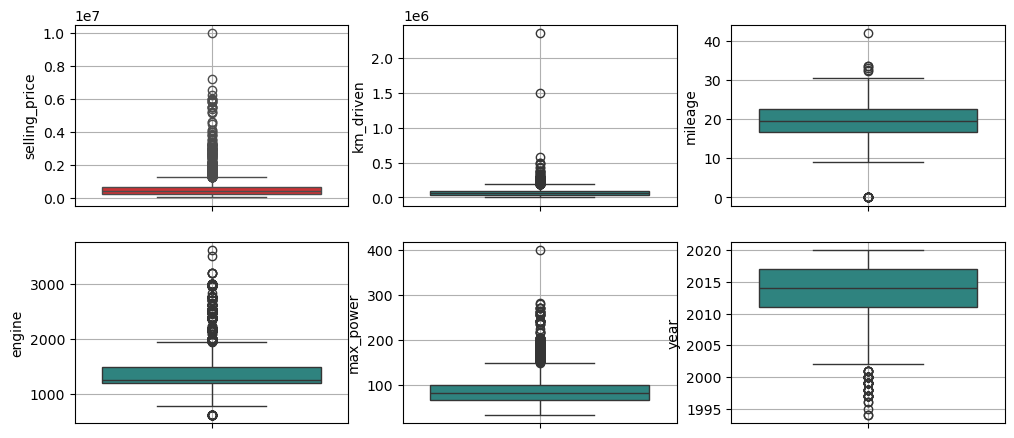

In [31]:
plt.figure(figsize=(12,8))

plt.subplot(3,3,1)
sns.boxplot(df['selling_price'], palette='Set1')
plt.grid(True)

plt.subplot(3,3,2)
sns.boxplot(df['km_driven'], palette='viridis')
plt.grid(True)

plt.subplot(3,3,3)
sns.boxplot(df['mileage'], palette='viridis')
plt.grid(True)

plt.subplot(3,3,4)
sns.boxplot(df['engine'], palette='viridis')
plt.grid(True)

plt.subplot(3,3,5)
sns.boxplot(df['max_power'], palette='viridis')
plt.grid(True)

plt.subplot(3,3,6)
sns.boxplot(df['year'], palette='viridis')
plt.grid(True)

plt.show()

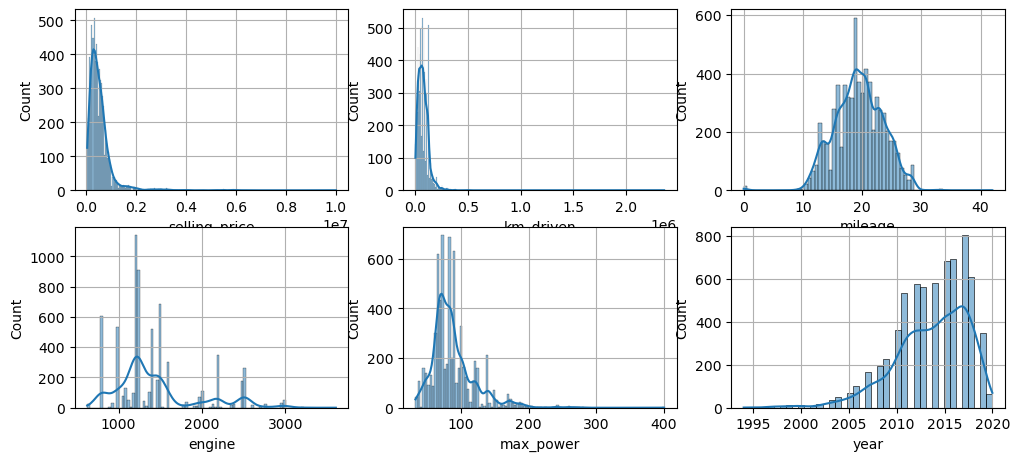

In [32]:
plt.figure(figsize=(12,8))

plt.subplot(3,3,1)
sns.histplot(df['selling_price'], palette='Set1', kde=True)
plt.grid(True)

plt.subplot(3,3,2)
sns.histplot(df['km_driven'], palette='viridis', kde=True)
plt.grid(True)

plt.subplot(3,3,3)
sns.histplot(df['mileage'], palette='viridis', kde=True)
plt.grid(True)

plt.subplot(3,3,4)
sns.histplot(df['engine'], palette='viridis', kde=True)
plt.grid(True)

plt.subplot(3,3,5)
sns.histplot(df['max_power'], palette='viridis', kde=True)
plt.grid(True)

plt.subplot(3,3,6)
sns.histplot(df['year'], palette='viridis', kde=True)
plt.grid(True)

plt.show()

In [33]:
df_copy = df.copy()
df_copy

,name,year,selling_price,km_driven,owner,mileage,engine,max_power,torque,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_Diesel,fuel_LPG,fuel_Petrol,transmission_Manual
0,Maruti Swift Dzire VDI,2014,450000,145500,1,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,1,0,1,0,0,1
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,2,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,1,0,1,0,0,1
2,Honda City 2017-2020 EXi,2006,158000,140000,3,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,1,0,0,0,1,1
3,Hyundai i20 Sportz Diesel,2010,225000,127000,1,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,1,0,1,0,0,1
4,Maruti Swift VXI BSIII,2007,130000,120000,1,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,2,18.90,998.0,67.10,90Nm@ 3500rpm,5.0,1,0,0,0,1,1
6713,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,2,22.54,1396.0,88.73,219.7Nm@ 1500-2750rpm,5.0,1,0,1,0,0,1
6714,Hyundai i20 Magna,2013,320000,110000,1,18.50,1197.0,82.85,113.7Nm@ 4000rpm,5.0,1,0,0,0,1,1
6715,Hyundai Verna CRDi SX,2007,135000,119000,4,16.80,1493.0,110.00,"24@ 1,900-2,750(kgm@ rpm)",5.0,1,0,1,0,0,1


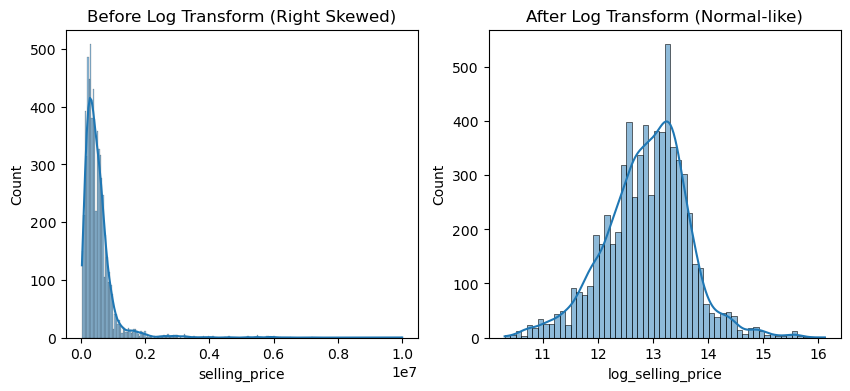

In [34]:
import numpy as np

# 1. Visualize the specific problem (Price)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['selling_price'], kde=True)
plt.title("Before Log Transform (Right Skewed)")

# 2. Apply the Fix (Log Transformation)
# We use log1p (log(1+x)) to avoid errors with 0 values
df_copy['log_selling_price'] = np.log1p(df['selling_price'])

# 3. Visualize the Result
plt.subplot(1,2,2)
sns.histplot(df_copy['log_selling_price'], kde=True)
plt.title("After Log Transform (Normal-like)")
plt.show()

In [35]:
df_copy.drop('selling_price', axis = 1, inplace = True)

In [36]:
df['brand'] = df['name'].str.split().str[0]
df.brand.unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Datsun', 'Jeep', 'Mercedes-Benz',
       'Mitsubishi', 'Audi', 'Volkswagen', 'BMW', 'Nissan', 'Lexus',
       'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo', 'Kia', 'Fiat', 'Force',
       'Ambassador', 'Ashok', 'Isuzu', 'Opel'], dtype=object)

In [37]:
df['brand'].value_counts()

brand
Maruti           2089
Hyundai          1214
Mahindra          709
Tata              633
Honda             361
Ford              353
Toyota            324
Chevrolet         216
Renault           206
Volkswagen        173
Nissan             73
Skoda              69
Datsun             57
Mercedes-Benz      46
BMW                45
Fiat               39
Audi               33
Jeep               22
Mitsubishi         11
Volvo               9
Jaguar              8
Isuzu               4
Ambassador          4
Force               4
Land                3
Kia                 3
Daewoo              3
MG                  3
Ashok               1
Lexus               1
Opel                1
Name: count, dtype: int64

In [38]:
df = pd.get_dummies(df, columns=['brand'], drop_first=True, dtype=int)

In [39]:
# Storing the cleaned and processed data into seperate variable data(if needed later or for experiment purpose)
data = df.copy()
data

,name,year,selling_price,km_driven,owner,mileage,engine,max_power,torque,seats,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,Maruti Swift Dzire VDI,2014,450000,145500,1,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,...,0,0,0,0,0,0,0,0,0,0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,2,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,...,0,0,0,0,0,1,0,0,0,0
2,Honda City 2017-2020 EXi,2006,158000,140000,3,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,...,0,0,0,0,0,0,0,0,0,0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,1,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,...,0,0,0,0,0,0,0,0,0,0
4,Maruti Swift VXI BSIII,2007,130000,120000,1,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,2,18.90,998.0,67.10,90Nm@ 3500rpm,5.0,...,0,0,0,0,0,0,0,0,0,0
6713,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,2,22.54,1396.0,88.73,219.7Nm@ 1500-2750rpm,5.0,...,0,0,0,0,0,0,0,0,0,0
6714,Hyundai i20 Magna,2013,320000,110000,1,18.50,1197.0,82.85,113.7Nm@ 4000rpm,5.0,...,0,0,0,0,0,0,0,0,0,0
6715,Hyundai Verna CRDi SX,2007,135000,119000,4,16.80,1493.0,110.00,"24@ 1,900-2,750(kgm@ rpm)",5.0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
df.drop(['name','torque'], axis=1,inplace=True)

In [41]:
df

,year,selling_price,km_driven,owner,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2014,450000,145500,1,23.40,1248.0,74.00,5.0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2014,370000,120000,2,21.14,1498.0,103.52,5.0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,2006,158000,140000,3,17.70,1497.0,78.00,5.0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2010,225000,127000,1,23.00,1396.0,90.00,5.0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2007,130000,120000,1,16.10,1298.0,88.20,5.0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,2013,260000,50000,2,18.90,998.0,67.10,5.0,1,0,...,0,0,0,0,0,0,0,0,0,0
6713,2014,475000,80000,2,22.54,1396.0,88.73,5.0,1,0,...,0,0,0,0,0,0,0,0,0,0
6714,2013,320000,110000,1,18.50,1197.0,82.85,5.0,1,0,...,0,0,0,0,0,0,0,0,0,0
6715,2007,135000,119000,4,16.80,1493.0,110.00,5.0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
# Derived feature Age from year
df['age'] = 2025 - df['year']

In [43]:
df

,year,selling_price,km_driven,owner,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,age
0,2014,450000,145500,1,23.40,1248.0,74.00,5.0,1,0,...,0,0,0,0,0,0,0,0,0,11
1,2014,370000,120000,2,21.14,1498.0,103.52,5.0,1,0,...,0,0,0,0,1,0,0,0,0,11
2,2006,158000,140000,3,17.70,1497.0,78.00,5.0,1,0,...,0,0,0,0,0,0,0,0,0,19
3,2010,225000,127000,1,23.00,1396.0,90.00,5.0,1,0,...,0,0,0,0,0,0,0,0,0,15
4,2007,130000,120000,1,16.10,1298.0,88.20,5.0,1,0,...,0,0,0,0,0,0,0,0,0,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,2013,260000,50000,2,18.90,998.0,67.10,5.0,1,0,...,0,0,0,0,0,0,0,0,0,12
6713,2014,475000,80000,2,22.54,1396.0,88.73,5.0,1,0,...,0,0,0,0,0,0,0,0,0,11
6714,2013,320000,110000,1,18.50,1197.0,82.85,5.0,1,0,...,0,0,0,0,0,0,0,0,0,12
6715,2007,135000,119000,4,16.80,1493.0,110.00,5.0,1,0,...,0,0,0,0,0,0,0,0,0,18


In [44]:
df.drop('year', axis=1, inplace =True)
df

,selling_price,km_driven,owner,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_Diesel,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,age
0,450000,145500,1,23.40,1248.0,74.00,5.0,1,0,1,...,0,0,0,0,0,0,0,0,0,11
1,370000,120000,2,21.14,1498.0,103.52,5.0,1,0,1,...,0,0,0,0,1,0,0,0,0,11
2,158000,140000,3,17.70,1497.0,78.00,5.0,1,0,0,...,0,0,0,0,0,0,0,0,0,19
3,225000,127000,1,23.00,1396.0,90.00,5.0,1,0,1,...,0,0,0,0,0,0,0,0,0,15
4,130000,120000,1,16.10,1298.0,88.20,5.0,1,0,0,...,0,0,0,0,0,0,0,0,0,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,260000,50000,2,18.90,998.0,67.10,5.0,1,0,0,...,0,0,0,0,0,0,0,0,0,12
6713,475000,80000,2,22.54,1396.0,88.73,5.0,1,0,1,...,0,0,0,0,0,0,0,0,0,11
6714,320000,110000,1,18.50,1197.0,82.85,5.0,1,0,0,...,0,0,0,0,0,0,0,0,0,12
6715,135000,119000,4,16.80,1493.0,110.00,5.0,1,0,1,...,0,0,0,0,0,0,0,0,0,18


In [45]:
df.duplicated().sum()

19

In [46]:
df.drop_duplicates(inplace=True)

In [47]:
df.reset_index(drop=True, inplace=True)

In [48]:
df1 = df.copy()

In [49]:
plt.figure(figsize=(120,80))
sns.heatmap(df.corr(),annot=True, annot_kws={'size': 30})

<Axes: >

### Model Training without scaling

In [50]:
x = df.drop('selling_price', axis = 1)
y = df['selling_price']

In [51]:
x

,km_driven,owner,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_Diesel,fuel_LPG,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,age
0,145500,1,23.40,1248.0,74.00,5.0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,11
1,120000,2,21.14,1498.0,103.52,5.0,1,0,1,0,...,0,0,0,0,1,0,0,0,0,11
2,140000,3,17.70,1497.0,78.00,5.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,19
3,127000,1,23.00,1396.0,90.00,5.0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,15
4,120000,1,16.10,1298.0,88.20,5.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6693,50000,2,18.90,998.0,67.10,5.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,12
6694,80000,2,22.54,1396.0,88.73,5.0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,11
6695,110000,1,18.50,1197.0,82.85,5.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,12
6696,119000,4,16.80,1493.0,110.00,5.0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,18


In [52]:
y

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
6693    260000
6694    475000
6695    320000
6696    135000
6697    382000
Name: selling_price, Length: 6698, dtype: int64

In [53]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=2)

In [54]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((5358, 43), (1340, 43), (5358,), (1340,))

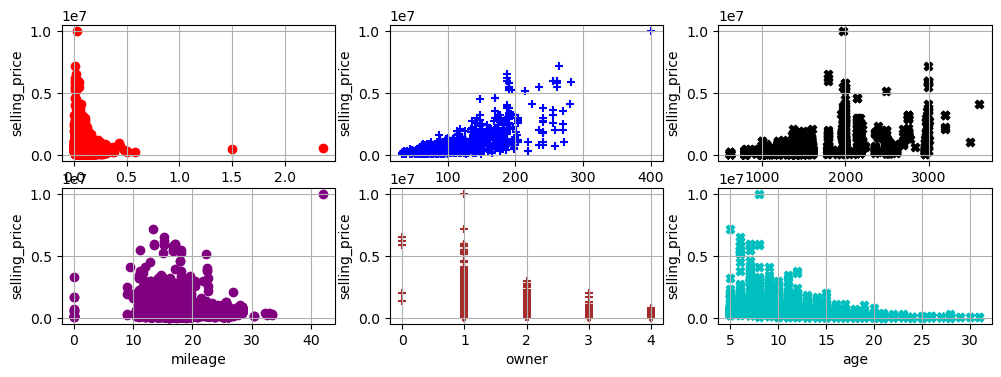

In [55]:
plt.figure(figsize=(12,6))

plt.subplot(3,3,1)
plt.scatter(df['km_driven'], df['selling_price'], color='red')
plt.xlabel('km_driven')
plt.ylabel('selling_price')
plt.grid()

plt.subplot(3,3,2)
plt.scatter(df['max_power'], df['selling_price'], color='blue',marker='+')
plt.xlabel('max_power')
plt.ylabel('selling_price')
plt.grid()

plt.subplot(3,3,3)
plt.scatter(df['engine'], df['selling_price'], color='black',marker='X')
plt.xlabel('engine')
plt.ylabel('selling_price')
plt.grid()

plt.subplot(3,3,4)
plt.scatter(df['mileage'], df['selling_price'], color='purple')
plt.xlabel('mileage')
plt.ylabel('selling_price')
plt.grid()

plt.subplot(3,3,5)
plt.scatter(df['owner'], df['selling_price'], color='brown',marker='+')
plt.xlabel('owner')
plt.ylabel('selling_price')
plt.grid()

plt.subplot(3,3,6)
plt.scatter(df['age'], df['selling_price'], color='c',marker='X')
plt.xlabel('age')
plt.ylabel('selling_price')
plt.grid()

In [56]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [57]:
y_pred = model.predict(x_test)
y_pred

array([ 833983.84535669,  353622.21788787,  375335.17452652, ...,
       2535848.07002769,  267370.034714  ,  332255.32062038])

In [58]:
model.coef_

array([-5.27087382e-01, -3.22725995e+04, -1.11736543e+03,  3.91152686e+01,
        6.04734226e+03,  1.00158782e+04, -6.46121923e+04, -8.81138846e+04,
        1.39563257e+05,  1.46742995e+05,  6.12899218e+04, -9.98070127e+04,
        1.86264515e-09,  7.93834479e+05,  8.69155562e+05, -4.19189244e+05,
        9.57455770e+04, -4.60591298e+05, -4.23471693e+05, -3.24928537e+05,
       -3.44238097e+05, -3.41974550e+05, -3.31579621e+05,  1.76932789e+05,
        9.52426668e+05,  1.23360012e+05,  2.18007117e+04,  1.26562846e+06,
        3.17240057e+06,  2.64094021e+05, -3.30219754e+05, -2.54868841e+05,
        6.82348996e+05, -9.08277359e+04, -3.53789699e+05,  2.32830644e-10,
       -3.65965230e+05, -3.12504252e+05, -4.23745044e+05, -4.60833626e+04,
       -4.08436939e+05,  2.35453400e+06, -4.07559671e+04])

In [59]:
model.intercept_

783778.3008746854

In [60]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)
adj_r2 = 1 -(1-R2)*(len(y_test) - 1)/(len(y_test)-x_test.shape[1]-1)

print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {R2} \nAdjusted R^2: {adj_r2} ')

Mean absolute error: 130302.59664980204 
Mean squared error: 63244539891.77148 
Root mean squared error: 251484.67128588867 
R^2: 0.7530777211827464 
Adjusted R^2: 0.7448850838454455 


### Actual vs Predicted plot

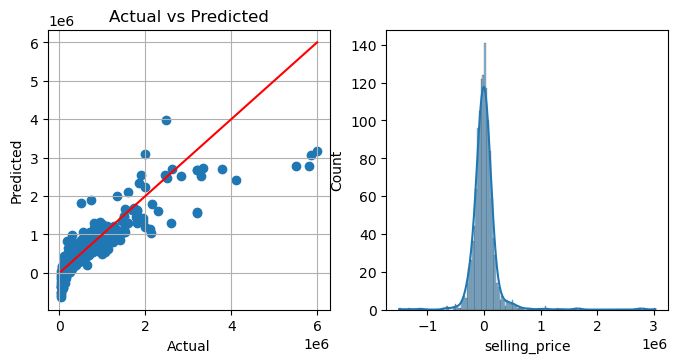

In [61]:
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.grid()

err = y_test - y_pred 
plt.subplot(2,2,2)
sns.histplot(err, kde=True)

plt.show()

## Model performs reasonably well for cheaper cars

## Model performs poorly for expensive cars

## Model is biased LOW for high-price cars

## The plot strongly suggests heteroscedasticity(non constant residual varaition)

In [62]:
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [63]:
scaled_model = LinearRegression()
scaled_model.fit(X_train, y_train)
Y_pred = scaled_model.predict(X_test)

In [64]:
Y_pred

array([ 833983.84531996,  353622.21788906,  375335.17452015, ...,
       2535848.07007026,  267370.034714  ,  332255.32061998])

In [65]:
scaled_model.coef_

array([-3.22285061e+04, -2.37161573e+04, -4.52888412e+03,  1.93873006e+04,
        1.92854868e+05,  9.81720010e+03, -1.96885872e+04, -5.23779383e+03,
        6.94572770e+04,  1.11295311e+04,  3.04158183e+04, -2.78501425e+04,
       -9.45874490e-11,  5.72360783e+04,  7.29360801e+04, -7.36823724e+04,
        2.26493830e+03, -4.24933498e+04, -2.99852656e+04, -8.87471316e+03,
       -7.82671930e+04, -7.55897569e+04, -1.26691333e+05,  4.83253260e+03,
        2.90812093e+04,  6.93757107e+03,  5.15713293e+02,  2.99394549e+04,
        4.33357317e+04,  6.24735558e+03, -1.02051319e+05, -1.18089107e+05,
        5.87364927e+04, -3.50701532e+03, -3.53379304e+04,  7.27595761e-12,
       -6.09527351e+04, -3.20604454e+04, -1.23699253e+05, -1.00808438e+04,
       -6.56047473e+04,  9.09126132e+04, -1.58680627e+05])

In [66]:
scaled_model.intercept_

529411.7756625607

In [67]:
MAE = mean_absolute_error(y_test, Y_pred)
MSE = mean_squared_error(y_test, Y_pred)
RMSE = root_mean_squared_error(y_test, Y_pred)
R2 = r2_score(y_test, Y_pred)
adj_r2 = 1 -(1-R2)*(len(y_test) - 1)/(len(y_test)-X_test.shape[1]-1)

print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {R2} \nAdjusted R^2: {adj_r2} ')

Mean absolute error: 130302.59664976614 
Mean squared error: 63244539891.41614 
Root mean squared error: 251484.67128518218 
R^2: 0.7530777211841337 
Adjusted R^2: 0.7448850838468789 


In [68]:
df_copy.dtypes

name                             object
year                              int64
km_driven                         int64
owner                             int64
mileage                         float64
engine                          float64
max_power                       float64
torque                           object
seats                           float64
seller_type_Individual            int32
seller_type_Trustmark Dealer      int32
fuel_Diesel                       int32
fuel_LPG                          int32
fuel_Petrol                       int32
transmission_Manual               int32
log_selling_price               float64
dtype: object

In [69]:
df_copy['brand'] = df_copy['name'].str.split().str[0]
df_copy.drop('name', axis=1, inplace=True)
df_copy

,year,km_driven,owner,mileage,engine,max_power,torque,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_Diesel,fuel_LPG,fuel_Petrol,transmission_Manual,log_selling_price,brand
0,2014,145500,1,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,1,0,1,0,0,1,13.017005,Maruti
1,2014,120000,2,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,1,0,1,0,0,1,12.821261,Skoda
2,2006,140000,3,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,1,0,0,0,1,1,11.970357,Honda
3,2010,127000,1,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,1,0,1,0,0,1,12.323860,Hyundai
4,2007,120000,1,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,1,0,0,0,1,1,11.775297,Maruti
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,2013,50000,2,18.90,998.0,67.10,90Nm@ 3500rpm,5.0,1,0,0,0,1,1,12.468441,Maruti
6713,2014,80000,2,22.54,1396.0,88.73,219.7Nm@ 1500-2750rpm,5.0,1,0,1,0,0,1,13.071072,Hyundai
6714,2013,110000,1,18.50,1197.0,82.85,113.7Nm@ 4000rpm,5.0,1,0,0,0,1,1,12.676079,Hyundai
6715,2007,119000,4,16.80,1493.0,110.00,"24@ 1,900-2,750(kgm@ rpm)",5.0,1,0,1,0,0,1,11.813037,Hyundai


In [70]:
df_copy = pd.get_dummies(df_copy, columns=['brand'], drop_first=True, dtype=int)

In [71]:
df_copy.reset_index(inplace=True)

In [72]:
df_copy

,index,year,km_driven,owner,mileage,engine,max_power,torque,seats,seller_type_Individual,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,0,2014,145500,1,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,2014,120000,2,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,1,...,0,0,0,0,0,1,0,0,0,0
2,2,2006,140000,3,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,1,...,0,0,0,0,0,0,0,0,0,0
3,3,2010,127000,1,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,1,...,0,0,0,0,0,0,0,0,0,0
4,4,2007,120000,1,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,6712,2013,50000,2,18.90,998.0,67.10,90Nm@ 3500rpm,5.0,1,...,0,0,0,0,0,0,0,0,0,0
6713,6713,2014,80000,2,22.54,1396.0,88.73,219.7Nm@ 1500-2750rpm,5.0,1,...,0,0,0,0,0,0,0,0,0,0
6714,6714,2013,110000,1,18.50,1197.0,82.85,113.7Nm@ 4000rpm,5.0,1,...,0,0,0,0,0,0,0,0,0,0
6715,6715,2007,119000,4,16.80,1493.0,110.00,"24@ 1,900-2,750(kgm@ rpm)",5.0,1,...,0,0,0,0,0,0,0,0,0,0


In [73]:
x = df_copy.drop(['torque','log_selling_price'], axis=1)

In [74]:
y = df_copy['log_selling_price']

In [75]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size= 0.2)

In [76]:
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
y_pred

array([13.42854773, 12.27394255, 10.97241472, ..., 13.05300766,
       12.624188  , 12.16390534])

In [77]:
model.coef_

array([ 1.07853062e-06,  1.15816033e-01, -1.97487012e-07, -6.09900844e-02,
        1.13827654e-03,  2.01769437e-04,  8.36790712e-03,  4.40150687e-02,
       -5.93876073e-02, -6.64953867e-05,  3.69621058e-01,  2.31359526e-01,
        1.45612225e-01, -6.45408801e-02, -2.90390767e-01,  2.99363430e-01,
        3.16418322e-01, -3.51698945e-01,  3.54997608e-01, -3.55404942e-01,
       -1.79270544e-01, -2.81947795e-01, -9.58419529e-02,  6.51840092e-02,
        1.43465670e-02, -1.08321954e-01,  1.90094615e-01,  6.78145001e-02,
        4.37667987e-02,  7.81764338e-01, -1.53628971e-10,  3.57351968e-01,
       -1.40466215e-01,  6.28781331e-02,  4.06363658e-01,  1.00614809e-01,
       -4.94725819e-02,  3.25170586e-01, -7.13236035e-02, -4.31756572e-02,
       -3.94757874e-01,  1.98780035e-01, -6.76447798e-02,  4.67301249e-01])

In [78]:
model.intercept_

-221.6210463220085

In [79]:
# Reverse Log

comparision = pd.DataFrame()
comparision['Actual'] = np.expm1(y_test)
comparision['Predicted'] = np.expm1(y_pred)

In [80]:
MAE = mean_absolute_error(comparision['Actual'], comparision['Predicted'])
MSE = mean_squared_error(comparision['Actual'], comparision['Predicted'])
RMSE = root_mean_squared_error(comparision['Actual'], comparision['Predicted'])
R2 = r2_score(y_test, y_pred)
adj_r2 = 1 -(1-R2)*(len(y_test) - 1)/(len(y_test)-x_test.shape[1]-1)

print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {R2} \nAdjusted R^2: {adj_r2} ')

Mean absolute error: 97433.3884911972 
Mean squared error: 45547734513.59766 
Root mean squared error: 213419.15217149013 
R^2: 0.8836788039928457 
Adjusted R^2: 0.8797387480849821 


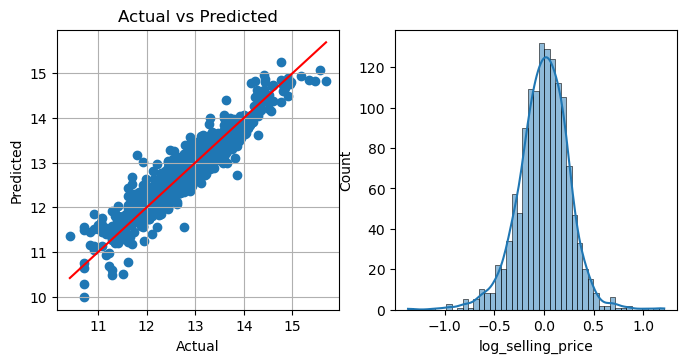

In [81]:
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.grid()

err = y_test - y_pred 
plt.subplot(2,2,2)
sns.histplot(err, kde=True)

plt.show()

In [82]:
df_copy['log_km_driven'] = np.log1p(df_copy['km_driven'])
df_copy

,index,year,km_driven,owner,mileage,engine,max_power,torque,seats,seller_type_Individual,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,log_km_driven
0,0,2014,145500,1,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,1,...,0,0,0,0,0,0,0,0,0,11.887938
1,1,2014,120000,2,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,1,...,0,0,0,0,1,0,0,0,0,11.695255
2,2,2006,140000,3,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,1,...,0,0,0,0,0,0,0,0,0,11.849405
3,3,2010,127000,1,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,1,...,0,0,0,0,0,0,0,0,0,11.751950
4,4,2007,120000,1,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,1,...,0,0,0,0,0,0,0,0,0,11.695255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,6712,2013,50000,2,18.90,998.0,67.10,90Nm@ 3500rpm,5.0,1,...,0,0,0,0,0,0,0,0,0,10.819798
6713,6713,2014,80000,2,22.54,1396.0,88.73,219.7Nm@ 1500-2750rpm,5.0,1,...,0,0,0,0,0,0,0,0,0,11.289794
6714,6714,2013,110000,1,18.50,1197.0,82.85,113.7Nm@ 4000rpm,5.0,1,...,0,0,0,0,0,0,0,0,0,11.608245
6715,6715,2007,119000,4,16.80,1493.0,110.00,"24@ 1,900-2,750(kgm@ rpm)",5.0,1,...,0,0,0,0,0,0,0,0,0,11.686887


In [83]:
df_copy.drop('km_driven', axis=1, inplace=True)

In [84]:
df_copy.drop('index', axis=1, inplace=True)

In [85]:
df_copy

,year,owner,mileage,engine,max_power,torque,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_Diesel,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,log_km_driven
0,2014,1,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,1,0,1,...,0,0,0,0,0,0,0,0,0,11.887938
1,2014,2,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,1,0,1,...,0,0,0,0,1,0,0,0,0,11.695255
2,2006,3,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,1,0,0,...,0,0,0,0,0,0,0,0,0,11.849405
3,2010,1,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,1,0,1,...,0,0,0,0,0,0,0,0,0,11.751950
4,2007,1,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,1,0,0,...,0,0,0,0,0,0,0,0,0,11.695255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,2013,2,18.90,998.0,67.10,90Nm@ 3500rpm,5.0,1,0,0,...,0,0,0,0,0,0,0,0,0,10.819798
6713,2014,2,22.54,1396.0,88.73,219.7Nm@ 1500-2750rpm,5.0,1,0,1,...,0,0,0,0,0,0,0,0,0,11.289794
6714,2013,1,18.50,1197.0,82.85,113.7Nm@ 4000rpm,5.0,1,0,0,...,0,0,0,0,0,0,0,0,0,11.608245
6715,2007,4,16.80,1493.0,110.00,"24@ 1,900-2,750(kgm@ rpm)",5.0,1,0,1,...,0,0,0,0,0,0,0,0,0,11.686887


In [86]:
df_copy.columns

Index(['year', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats',
       'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_Diesel',
       'fuel_LPG', 'fuel_Petrol', 'transmission_Manual', 'log_selling_price',
       'brand_Ashok', 'brand_Audi', 'brand_BMW', 'brand_Chevrolet',
       'brand_Daewoo', 'brand_Datsun', 'brand_Fiat', 'brand_Force',
       'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Isuzu',
       'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land', 'brand_Lexus',
       'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz',
       'brand_Mitsubishi', 'brand_Nissan', 'brand_Opel', 'brand_Renault',
       'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen',
       'brand_Volvo', 'log_km_driven'],
      dtype='object')

In [87]:
x = df_copy.drop(['log_selling_price','torque'], axis=1)

In [88]:
y = df_copy['log_selling_price']

In [89]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [90]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred

array([13.37427855, 11.90164213, 12.45166138, ..., 11.72111947,
       12.37061862, 13.25748271])

In [91]:
model.coef_

array([ 1.12857043e-01, -5.99818681e-02,  1.11426456e-03,  2.08028026e-04,
        8.34994271e-03,  4.19150190e-02, -4.67136261e-02,  9.87920580e-03,
        3.83111728e-01,  2.24477552e-01,  1.40158424e-01, -4.70356441e-02,
        2.55351296e-15, -4.99912034e-02, -8.40156247e-02, -7.86788907e-01,
       -1.02346243e-01, -7.81950520e-01, -6.46353880e-01, -7.32719539e-01,
       -5.44067724e-01, -3.79105358e-01, -4.21978629e-01, -5.62598825e-01,
       -2.28525458e-01, -4.03418894e-01, -1.43087085e-01,  4.31735780e-01,
        1.96242341e-01, -1.30518935e-01, -5.70748634e-01, -3.69372171e-01,
        3.21719011e-03, -2.84580883e-01, -4.49779985e-01, -1.32272019e-01,
       -5.21684260e-01, -4.94714562e-01, -8.40048912e-01, -2.33113585e-01,
       -4.79508528e-01,  1.52521480e-02, -4.17199212e-02])

In [92]:
model.intercept_

-214.81053614844825

In [93]:
# Reverse Log

comparision = pd.DataFrame()
comparision['Actual'] = np.expm1(y_test)
comparision['Predicted'] = np.expm1(y_pred)

err = comparision['Actual'], comparision['Predicted']

In [94]:
MAE = mean_absolute_error(comparision['Actual'], comparision['Predicted'])
MSE = mean_squared_error(comparision['Actual'], comparision['Predicted'])
RMSE = root_mean_squared_error(comparision['Actual'], comparision['Predicted'])
R2 = r2_score(y_test, y_pred)
adj_r2 = 1 -(1-R2)*(len(y_test) - 1)/(len(y_test)-x_test.shape[1]-1)

print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {R2} \nAdjusted R^2: {adj_r2} ')

Mean absolute error: 98056.56429053683 
Mean squared error: 35727098050.56459 
Root mean squared error: 189016.1317204555 
R^2: 0.8808598153057322 
Adjusted R^2: 0.8769190245812295 


# Evaluation

Metrics Used

    R² Score

    Adjusted R²

    MAE

    MSE

    RMSE

Performance Summary (Test Set)

    R² ≈ 0.88

    Adjusted R² ≈ 0.87

Interpretation

    The model explains ~80–88% of the variance in used car prices after log transformation, indicating a strong linear relationship between predictors and target.

    Performance is stable across train and test sets, suggesting limited overfitting.

    Predictions are most accurate for low-to-mid price vehicles, which dominate the dataset.

    The model still shows minor underprediction for very high-priced cars, a known limitation of linear regression under skewed distributions.

    Residuals are approximately normally distributed and centered around zero, validating core regression assumptions after transformation.

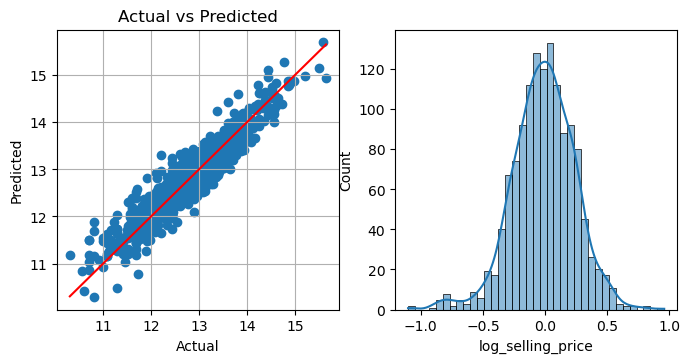

In [95]:
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.grid()

err = y_test - y_pred 
plt.subplot(2,2,2)
sns.histplot(err, kde=True)
plt.show()

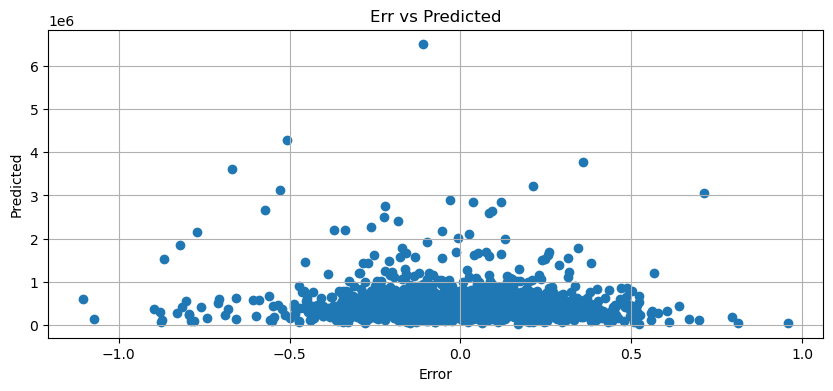

In [96]:
plt.figure(figsize=(10,4))
plt.scatter(err, comparision['Predicted'])
plt.xlabel('Error')
plt.ylabel('Predicted')
plt.title('Err vs Predicted')
plt.grid(True)
plt.show()

### Note: 
All transformations were fitted on training data and applied to test data to avoid data leakage.

Evaluation is based on a single train-test split; cross-validation is left for future work.

# Final Model Decision

After evaluating multiple preprocessing strategies, the final model was trained using log-transformed target (log_selling_price) and log-transformed km_driven.
This configuration achieved the best balance between performance, stability, and interpretability and is treated as the baseline model for this project.

In [97]:

df2 =df_copy.copy()
df2['age'] = 2025 - df2['year']
df2.drop(['year', 'torque'], axis = 1, inplace=True)

In [98]:
df_c = df2.copy()

# Applying Regularization & Hyperparameter tuning

In [99]:
df2

,owner,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_Diesel,fuel_LPG,fuel_Petrol,...,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,log_km_driven,age
0,1,23.40,1248.0,74.00,5.0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,11.887938,11
1,2,21.14,1498.0,103.52,5.0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,11.695255,11
2,3,17.70,1497.0,78.00,5.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,11.849405,19
3,1,23.00,1396.0,90.00,5.0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,11.751950,15
4,1,16.10,1298.0,88.20,5.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,11.695255,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,2,18.90,998.0,67.10,5.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,10.819798,12
6713,2,22.54,1396.0,88.73,5.0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,11.289794,11
6714,1,18.50,1197.0,82.85,5.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,11.608245,12
6715,4,16.80,1493.0,110.00,5.0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,11.686887,18


In [100]:
x = df2.drop('log_selling_price', axis = 1)
x

,owner,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_Diesel,fuel_LPG,fuel_Petrol,...,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,log_km_driven,age
0,1,23.40,1248.0,74.00,5.0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,11.887938,11
1,2,21.14,1498.0,103.52,5.0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,11.695255,11
2,3,17.70,1497.0,78.00,5.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,11.849405,19
3,1,23.00,1396.0,90.00,5.0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,11.751950,15
4,1,16.10,1298.0,88.20,5.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,11.695255,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6712,2,18.90,998.0,67.10,5.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,10.819798,12
6713,2,22.54,1396.0,88.73,5.0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,11.289794,11
6714,1,18.50,1197.0,82.85,5.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,11.608245,12
6715,4,16.80,1493.0,110.00,5.0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,11.686887,18


In [101]:
y = df2['log_selling_price']
y

0       13.017005
1       12.821261
2       11.970357
3       12.323860
4       11.775297
          ...    
6712    12.468441
6713    13.071072
6714    12.676079
6715    11.813037
6716    12.853179
Name: log_selling_price, Length: 6717, dtype: float64

In [102]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=1)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((5373, 43), (1344, 43), (5373,), (1344,))

In [103]:
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [104]:
# Ridge -->

ridge = Ridge()

params = {'alpha' : [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

ridge_model = GridSearchCV(estimator=ridge, param_grid=params, cv=5, return_train_score=True, scoring='r2')
ridge_model.fit(X_train,y_train)
print('Best parameter : ',ridge_model.best_params_,'\n')
print('Best score : ',ridge_model.best_score_,'\n')
print('Best estimator : ',ridge_model.best_estimator_,'\n')

y_pred_ridge = ridge_model.predict(X_test)
print('y_predict : \n',y_pred_ridge)

print(pd.DataFrame(ridge_model.cv_results_)[['params', 'mean_train_score', 'mean_test_score']])

print('\n\nBefore Reversing log transformations\n')
MAE = mean_absolute_error(y_test, y_pred_ridge)
MSE = mean_squared_error(y_test, y_pred_ridge)
r2 = r2_score(y_test, y_pred_ridge)
RMSE = root_mean_squared_error(y_test, y_pred_ridge)
adj_r2 = 1 -(1-r2)*(len(y_test) - 1)/(len(y_test)-X_test.shape[1]-1)
print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {r2} \nAdjusted R^2: {adj_r2} ')

print('\n\nAfter Reversing log transformations\n')
# Reverse Log
comparision = pd.DataFrame()
comparision['Actual'] = np.expm1(y_test)
comparision['Predicted'] = np.expm1(y_pred_ridge)


MAE = mean_absolute_error(comparision['Actual'], comparision['Predicted'])
MSE = mean_squared_error(comparision['Actual'], comparision['Predicted'])
RMSE = root_mean_squared_error(comparision['Actual'], comparision['Predicted'])
R2 = r2_score(y_test, y_pred_ridge)
adj_r2 = 1 -(1-R2)*(len(y_test) - 1)/(len(y_test)-X_test.shape[1]-1)

print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {R2} \nAdjusted R^2: {adj_r2} ')

Best parameter :  {'alpha': 1} 

Best score :  0.8878438841673626 

Best estimator :  Ridge(alpha=1) 

y_predict : 
 [13.37406235 11.90174849 12.45133337 ... 11.72130597 12.37106025
 13.25776645]
             params  mean_train_score  mean_test_score
0  {'alpha': 0.001}          0.891413         0.887791
1   {'alpha': 0.01}          0.891413         0.887792
2    {'alpha': 0.1}          0.891413         0.887802
3      {'alpha': 1}          0.891398         0.887844
4     {'alpha': 10}          0.891254         0.887728
5    {'alpha': 100}          0.890491         0.887074
6   {'alpha': 1000}          0.872294         0.869466


Before Reversing log transformations

Mean absolute error: 0.1936521657947877 
Mean squared error: 0.06321190533127104 
Root mean squared error: 0.2514197791170596 
R^2: 0.8813163179711654 
Adjusted R^2: 0.8773906269502116 


After Reversing log transformations

Mean absolute error: 97982.06946011903 
Mean squared error: 35685163690.06745 
Root mean squared er

In [105]:
# Lasso -->

lasso = Lasso()

params = {'alpha' : [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

lasso_model = GridSearchCV(estimator=lasso, param_grid=params, cv=5, return_train_score=True, scoring='r2', verbose=2)
lasso_model.fit(X_train,y_train)
print('Best parameter : ',lasso_model.best_params_,'\n')
print('Best score : ',lasso_model.best_score_,'\n')
print('Best estimator : ',lasso_model.best_estimator_,'\n')

y_pred_lasso = lasso_model.predict(X_test)
print('y_predict : \n',y_pred_lasso)

print(pd.DataFrame(lasso_model.cv_results_)[['params', 'mean_train_score', 'mean_test_score']])

print('\n\nBefore Reversing log transformations\n')
MAE = mean_absolute_error(y_test, y_pred_lasso)
MSE = mean_squared_error(y_test, y_pred_lasso)
r2 = r2_score(y_test, y_pred_lasso)
RMSE = root_mean_squared_error(y_test, y_pred_lasso)
adj_r2 = 1 -(1-r2)*(len(y_test) - 1)/(len(y_test)-X_test.shape[1]-1)
print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {r2} \nAdjusted R^2: {adj_r2} ')

print('\n\nAfter Reversing log transformations\n')
# Reverse Log
comparision = pd.DataFrame()
comparision['Actual'] = np.expm1(y_test)
comparision['Predicted'] = np.expm1(y_pred_lasso)


MAE = mean_absolute_error(comparision['Actual'], comparision['Predicted'])
MSE = mean_squared_error(comparision['Actual'], comparision['Predicted'])
RMSE = root_mean_squared_error(comparision['Actual'], comparision['Predicted'])
R2 = r2_score(y_test, y_pred_lasso)
adj_r2 = 1 -(1-R2)*(len(y_test) - 1)/(len(y_test)-X_test.shape[1]-1)

print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {R2} \nAdjusted R^2: {adj_r2} ')

Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ........................................

In [106]:
# Elastic Net -->

elastic_net = ElasticNet()

params = {'alpha' : [0.001, 0.01, 0.1, 1, 10, 100, 1000], 'l1_ratio' : [0, 0.25, 0.5, 0.75, 1]}

EN_model = GridSearchCV(estimator=elastic_net, param_grid=params, cv=5, return_train_score=True, scoring='r2', verbose=2)
EN_model.fit(X_train,y_train)
print('Best parameter : ',EN_model.best_params_,'\n')
print('Best score : ',EN_model.best_score_,'\n')
print('Best estimator : ',EN_model.best_estimator_,'\n')

y_pred_EN = EN_model.predict(X_test)
print('y_predict : \n',y_pred_EN)

print('\n\nBefore Reversing log transformations\n')
MAE = mean_absolute_error(y_test, y_pred_EN)
MSE = mean_squared_error(y_test, y_pred_EN)
r2 = r2_score(y_test, y_pred_EN)
RMSE = root_mean_squared_error(y_test, y_pred_EN)
adj_r2 = 1 -(1-r2)*(len(y_test) - 1)/(len(y_test)-X_test.shape[1]-1)
print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {r2} \nAdjusted R^2: {adj_r2} ')

print('\n\nAfter Reversing log transformations\n')
# Reverse Log
comparision = pd.DataFrame()
comparision['Actual'] = np.expm1(y_test)
comparision['Predicted'] = np.expm1(y_pred_EN)


MAE = mean_absolute_error(comparision['Actual'], comparision['Predicted'])
MSE = mean_squared_error(comparision['Actual'], comparision['Predicted'])
RMSE = root_mean_squared_error(comparision['Actual'], comparision['Predicted'])
R2 = r2_score(y_test, y_pred_EN)
adj_r2 = 1 -(1-R2)*(len(y_test) - 1)/(len(y_test)-X_test.shape[1]-1)

print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {R2} \nAdjusted R^2: {adj_r2} ')

Fitting 5 folds for each of 35 candidates, totalling 175 fits
[CV] END ............................alpha=0.001, l1_ratio=0; total time=   0.2s
[CV] END ............................alpha=0.001, l1_ratio=0; total time=   0.1s
[CV] END ............................alpha=0.001, l1_ratio=0; total time=   0.1s
[CV] END ............................alpha=0.001, l1_ratio=0; total time=   0.1s
[CV] END ............................alpha=0.001, l1_ratio=0; total time=   0.1s
[CV] END .........................alpha=0.001, l1_ratio=0.25; total time=   0.0s
[CV] END .........................alpha=0.001, l1_ratio=0.25; total time=   0.0s
[CV] END .........................alpha=0.001, l1_ratio=0.25; total time=   0.0s
[CV] END .........................alpha=0.001, l1_ratio=0.25; total time=   0.0s
[CV] END .........................alpha=0.001, l1_ratio=0.25; total time=   0.0s
[CV] END ..........................alpha=0.001, l1_ratio=0.5; total time=   0.0s
[CV] END ..........................alpha=0.001,

### Ridge regression shrinks coefficients smoothly, while Lasso forces some coefficients closer to zero, confirming expected regularization behavior.


## Model Comparison Summary

| Model | CV Strategy | R² (Test) | Adj R² | Comment |
|------|------------|----------|--------|--------|
| Linear Regression | Train-Test | ~0.8808 | ~0.8769 | Baseline |
| Ridge Regression | CV (α tuned) | ~0.8813 | ~0.8773 | More stable coefficients |
| Lasso Regression | CV (α tuned) | ~0.8825 | ~0.8786 | Feature sparsity, slight underfit |

**Conclusion:**  
Regularization improved coefficient stability and generalization consistency, but did not significantly outperform the baseline in R² — indicating the baseline model was already well-regularized via preprocessing and transformations.



### Why Regularization Did Not Dramatically Improve R²

- The baseline model already handled skewness via log transformation
- Multicollinearity was present but not severe enough to cause overfitting
- Regularization primarily improved coefficient stability, not raw accuracy
- This behavior is expected in well-preprocessed linear models

Hence, regularization was applied for robustness rather than performance gains.


In [ ]:
df2.columns

In [ ]:
x = df2.drop('log_selling_price', axis=1)
y = df2['log_selling_price']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=1)

from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
# Reverse Log
comparision = pd.DataFrame()
comparision['Actual'] = np.expm1(y_test)
comparision['Predicted'] = np.expm1(y_pred_EN)


MAE = mean_absolute_error(comparision['Actual'], comparision['Predicted'])
MSE = mean_squared_error(comparision['Actual'], comparision['Predicted'])
RMSE = root_mean_squared_error(comparision['Actual'], comparision['Predicted'])
R2 = r2_score(y_test, y_pred)
adj_r2 = 1 -(1-R2)*(len(y_test) - 1)/(len(y_test)-x_test.shape[1]-1)

print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {R2} \nAdjusted R^2: {adj_r2} ')

Mean absolute error: 97855.12913331928 
Mean squared error: 35612667456.34523 
Root mean squared error: 188713.18834767546 
R^2: 0.8583378579702774 
Adjusted R^2: 0.8536521101954481 


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=1)

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
params = {'max_depth' : [3,5,7,10,15], 'min_samples_leaf' : [1,2,5,10,20], 'criterion':['squared_error', 'absolute_error', 'friedman_mse']}
clf = DecisionTreeRegressor()

model = GridSearchCV(clf, param_grid=params, cv = 5, verbose=3)
model.fit(x_train, y_train)
best_model = model.best_estimator_
y_pred = best_model.predict(x_test)

from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
# Reverse Log
comparision = pd.DataFrame()
comparision['Actual'] = np.expm1(y_test)
comparision['Predicted'] = np.expm1(y_pred_EN)


MAE = mean_absolute_error(comparision['Actual'], comparision['Predicted'])
MSE = mean_squared_error(comparision['Actual'], comparision['Predicted'])
RMSE = root_mean_squared_error(comparision['Actual'], comparision['Predicted'])
R2 = r2_score(y_test, y_pred)
adj_r2 = 1 -(1-R2)*(len(y_test) - 1)/(len(y_test)-x_test.shape[1]-1)

print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {R2} \nAdjusted R^2: {adj_r2} ')

Fitting 5 folds for each of 75 candidates, totalling 375 fits
[CV 1/5] END criterion=squared_error, max_depth=3, min_samples_leaf=1;, score=0.711 total time=   0.0s
[CV 2/5] END criterion=squared_error, max_depth=3, min_samples_leaf=1;, score=0.681 total time=   0.0s
[CV 3/5] END criterion=squared_error, max_depth=3, min_samples_leaf=1;, score=0.750 total time=   0.0s
[CV 4/5] END criterion=squared_error, max_depth=3, min_samples_leaf=1;, score=0.731 total time=   0.0s
[CV 5/5] END criterion=squared_error, max_depth=3, min_samples_leaf=1;, score=0.710 total time=   0.0s
[CV 1/5] END criterion=squared_error, max_depth=3, min_samples_leaf=2;, score=0.711 total time=   0.0s
[CV 2/5] END criterion=squared_error, max_depth=3, min_samples_leaf=2;, score=0.681 total time=   0.0s
[CV 3/5] END criterion=squared_error, max_depth=3, min_samples_leaf=2;, score=0.750 total time=   0.0s
[CV 4/5] END criterion=squared_error, max_depth=3, min_samples_leaf=2;, score=0.731 total time=   0.0s
[CV 5/5] EN

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=1)

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
params = {'max_depth' : [3,5,7,10,15], 'min_samples_leaf' : [1,2,5,10,20]}
clf = DecisionTreeRegressor()

model = GridSearchCV(clf, param_grid=params, cv = 5, verbose=3)
model.fit(x_train, y_train)
best_model = model.best_estimator_
best_param = model.best_params_
y_pred = best_model.predict(x_test)

from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
# Reverse Log
comparision = pd.DataFrame()
comparision['Actual'] = np.expm1(y_test)
comparision['Predicted'] = np.expm1(y_pred_EN)


MAE = mean_absolute_error(comparision['Actual'], comparision['Predicted'])
MSE = mean_squared_error(comparision['Actual'], comparision['Predicted'])
RMSE = root_mean_squared_error(comparision['Actual'], comparision['Predicted'])
R2 = r2_score(y_test, y_pred)
adj_r2 = 1 -(1-R2)*(len(y_test) - 1)/(len(y_test)-x_test.shape[1]-1)
print('Best Parameter : ',best_param)
print(f'Mean absolute error: {MAE} \nMean squared error: {MSE} \nRoot mean squared error: {RMSE} \nR^2: {R2} \nAdjusted R^2: {adj_r2} ')

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ...max_depth=3, min_samples_leaf=1;, score=0.711 total time=   0.0s
[CV 2/5] END ...max_depth=3, min_samples_leaf=1;, score=0.681 total time=   0.0s
[CV 3/5] END ...max_depth=3, min_samples_leaf=1;, score=0.750 total time=   0.0s
[CV 4/5] END ...max_depth=3, min_samples_leaf=1;, score=0.731 total time=   0.0s
[CV 5/5] END ...max_depth=3, min_samples_leaf=1;, score=0.710 total time=   0.0s
[CV 1/5] END ...max_depth=3, min_samples_leaf=2;, score=0.711 total time=   0.0s
[CV 2/5] END ...max_depth=3, min_samples_leaf=2;, score=0.681 total time=   0.0s
[CV 3/5] END ...max_depth=3, min_samples_leaf=2;, score=0.750 total time=   0.0s
[CV 4/5] END ...max_depth=3, min_samples_leaf=2;, score=0.731 total time=   0.0s
[CV 5/5] END ...max_depth=3, min_samples_leaf=2;, score=0.710 total time=   0.0s
[CV 1/5] END ...max_depth=3, min_samples_leaf=5;, score=0.711 total time=   0.0s
[CV 2/5] END ...max_depth=3, min_samples_leaf=5

## Model Comparison — Ensemble Methods
Moving beyond linear models to compare tree-based approaches.
Log-transformed target and features retained from final Linear Regression setup.

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10),
    'Lasso': Lasso(alpha=0.01),
    'Decision Tree' : DecisionTreeRegressor(max_depth = 10, min_samples_leaf = 10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
}

results = {}
for name, m in models.items():
    m.fit(x_train, y_train)
    pred = m.predict(x_test)
    results[name] = {
        'R2': round(r2_score(y_test, pred), 4)*100
    }

pd.DataFrame(results).T

,R2
Linear Regression,88.09
Ridge,88.29
Lasso,85.69
Decision Tree,89.00
Random Forest,91.63
XGBoost,92.21


In [108]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)  
y_pred

print('R2', r2_score(y_test, y_pred))

R2 0.9220892118410742


## Final Model Comparison

| Model             | R² Score | Notes                          |
|-------------------|----------|--------------------------------|
| Linear Regression | 0.8809   | Baseline                       |
| Ridge             | 0.8829   | Marginal improvement           |
| Lasso             | 0.8569   | Slight underfitting            |
| Decision Tree     | 0.8900   | Overfitting risk               |
| Random Forest     | 0.9163   | Strong ensemble                |
| XGBoost           | 0.9221   | ✅ Best — selected for deployment |

**Deployed model:** XGBoost (R² = 92.21%)  
**Live demo:** https://huggingface.co/spaces/ManojSabale/Car_Price_Predictor

In [109]:
# ── Run this at the END of your notebook, after XGBoost is trained ──────────
import joblib

# 1. Save the trained XGBoost model
joblib.dump(xgb_model, 'model.pkl')

# 2. Save the exact column list used during training
joblib.dump(list(x_train.columns), 'model_columns.pkl')

print("Saved: model.pkl")
print("Saved: model_columns.pkl")
print(f"Columns saved: {len(x_train.columns)}")
print(x_train.columns.tolist())

Saved: model.pkl
Saved: model_columns.pkl
Columns saved: 43
['owner', 'mileage', 'engine', 'max_power', 'seats', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'transmission_Manual', 'brand_Ashok', 'brand_Audi', 'brand_BMW', 'brand_Chevrolet', 'brand_Daewoo', 'brand_Datsun', 'brand_Fiat', 'brand_Force', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Isuzu', 'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land', 'brand_Lexus', 'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz', 'brand_Mitsubishi', 'brand_Nissan', 'brand_Opel', 'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen', 'brand_Volvo', 'log_km_driven', 'age']
